# Exercise 3 — Thermostat Effects on Water Observables

**MARVEL–ICTP School 2026**

In this exercise you compare three simulation protocols — **NVE**, **NVT (Nosé–Hoover)**, and **NVT (Langevin)** — across two water models (SPC/Fw and TIP3P). The NVE trajectories come from Exercise 2; you run the two NVT simulations here.

For each run you will compute:

1. **E_tot drift** (NVE) and **T(t) control** (all thermostats)
2. **Radial distribution functions** $g_{\mathrm{OO}}(r)$ and $g_{\mathrm{OH}}(r)$
3. **VACF** and self-diffusion coefficient $D_\mathrm{VACF}$
4. **MSD** and self-diffusion coefficient $D_\mathrm{MSD}$
5. **Rotational relaxation time** $\tau_2$

A summary table at the end collects all six $(\text{model} \times \text{thermostat})$ combinations and compares them with experiment.

## 1. Theory

### Radial distribution function

The **radial distribution function** $g_{AB}(r)$ is the probability of finding a particle of species $B$ at distance $r$ from a particle of species $A$, relative to an ideal gas at the same density:

$$g_{AB}(r) = \frac{V}{N_A N_B} \left\langle \sum_{i \in A} \sum_{j \in B,\, j\neq i} \delta(r - |\mathbf{r}_i - \mathbf{r}_j|) \right\rangle \frac{1}{4\pi r^2}$$

For liquid water, key features are:
- **$g_{\mathrm{OO}}(r)$**: first peak ~2.8 Å (first solvation shell, $\sim$4–5 neighbours), second peak ~4.5 Å
- **$g_{\mathrm{OH}}(r)$**: first peak ~1.8–2.0 Å (O···H hydrogen bond distance)
- **$g_{\mathrm{HH}}(r)$**: first peak ~2.4 Å (intra-molecular H–H, for flexible models), intermolecular at ~2.5 Å and beyond

The $g(r)$ encodes the **liquid structure** and is set by the force field; thermostats should leave it unchanged.

---

### Orientational autocorrelation function and $\tau_2$

Consider the unit vector $\hat{\mathbf{u}}_i(t)$ along the molecular dipole of molecule $i$ at time $t$. Its **rotational autocorrelation functions** are:

$$C_\ell(t) = \left\langle P_\ell\!\left(\hat{\mathbf{u}}_i(0) \cdot \hat{\mathbf{u}}_i(t)\right) \right\rangle$$

where $P_\ell$ is the Legendre polynomial of order $\ell$:

$$P_1(x) = x \qquad P_2(x) = \tfrac{1}{2}(3x^2 - 1)$$

$C_1(0) = C_2(0) = 1$ by definition. Both decay to zero as the molecule reorients: $C_1$ is accessible via IR/dielectric spectroscopy; $C_2$ is accessible via **NMR relaxation** ($^1$H, $^{17}$O) and Raman spectroscopy.

In the diffusive (tumbling) regime at long times, both decay exponentially:

$$C_\ell(t) \approx A_\ell \, e^{-t/\tau_\ell}$$

For isotropic diffusive rotation the two times are related by $\tau_1 = 3\,\tau_2$. In water at 298 K, $\tau_2^\mathrm{exp} \approx 2$ ps (from $^{17}$O NMR $T_1$).

**How to extract $\tau_2$:**

1. **Integral method** (robust to noise at long times):
   $$\tau_2 = \int_0^\infty C_2(t)\, dt$$
   Works well if $C_2$ decays to zero within the trajectory.

2. **Exponential fit** (more direct but sensitive to the fit window):
   Fit $C_2(t) = e^{-t/\tau_2}$ in the range where the decay is roughly exponential — typically after the fast librational component (~0.2 ps) and before the noise floor (~5–10 ps for a 100 ps run).

**Thermostat effects:** The Langevin thermostat adds friction on every degree of freedom, including rotational ones, leading to artificially fast decay of $C_2$ and an underestimated $\tau_2$. The Nosé–Hoover thermostat affects $C_2$ much less because it acts globally on the kinetic energy, not on individual velocities.

## 2. Instructions

### Step 1 — Reuse the NVE trajectories from Exercise 2

No LAMMPS run needed. The NVE trajectories are read directly from:
```
../exercise_2/simulations/spcfw_prod/traj.lammpstrj
../exercise_2/simulations/tip3p_prod/traj.lammpstrj
```

### Step 2 — Run the NVT productions

```bash
cd simulations/spcfw_nvt_nh
lmp -in ../../in.spcfw.nvt_nh.lammps

cd simulations/spcfw_nvt_langevin
lmp -in ../../in.spcfw.nvt_langevin.lammps

cd simulations/tip3p_nvt_nh
lmp -in ../../in.tip3p.nvt_nh.lammps

cd simulations/tip3p_nvt_langevin
lmp -in ../../in.tip3p.nvt_langevin.lammps
```

If you want, you can also launch all four runs with:
```bash
bash run_exercise_3_sims.sh
```

Default length: 100 ps. Add `-var nsteps 400000` for 200 ps (better statistics).

### Step 3 — Set the pre-computation parameter

Before running the pre-computation cells, set `ROT_TMAX_PS` in the **Pre-computation configuration** cell below. This controls the maximum lag time used for the rotational-relaxation calculation.

### Step 4 — Run the pre-computation cells once

The two pre-computation cells compute g(r), rotational relaxation, VACF, and MSD for all available trajectories and save results as CSV files. Re-run only when new trajectories become available.

### Step 5 — Set analysis windows (student config cell)

Fill in `VACF_TMAX_FS` and the MSD fit windows — the same diffusion-analysis values you found in Exercise 2 are a good starting point.

## 3. Setup

In [73]:
from __future__ import annotations
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.grid": True,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.titlesize": 16,
    "legend.fontsize": 10,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT    = Path(".").resolve()          # exercise_3/
SIM     = ROOT / "simulations"
EX2_SIM = ROOT / ".." / "exercise_2_myv" / "simulations"
SCRIPTS = ROOT / "analysis_scripts"
sys.path.insert(0, str(SCRIPTS))

import msd_vacf as mv

# Unit conversion
T_AU_FS              = 2.4188843265857e-2
BOHR_M               = 5.29177210903e-11
T_AU_S               = 2.4188843265857e-17
AU_DIFF_TO_1E5_CM2_S = (BOHR_M**2 / T_AU_S) * 1e7 * 1e2

D_EXP   = 2.30   # [1e-5 cm^2/s]
TAU2_EXP = 2.0   # [ps] experimental tau_2 at 298 K

DUMP_DT_FS = 50.0  # 100 steps × 0.5 fs
TYPE_MAP   = {1: "O", 2: "H"}

MODELS = {
    "spcfw": {"label": "SPC/Fw",        "color": "#1f77b4"},
    "tip3p": {"label": "TIP3P (rigid)", "color": "#d62728"},
}

THERMOSTATS = {
    "nve":      {"label": "NVE",            "ls": "-",  "lw": 1.5, "color": "g"},
    "nvt_nh":   {"label": "NVT (NH)",       "ls": "--", "lw": 1.5, "color": "b"},
    "nvt_lang": {"label": "NVT (Langevin)", "ls": ":",  "lw": 2.0, "color": "r"},
}

THERMO_DIR = {
    "nve": "prod",
    "nvt_nh": "nvt_nh",
    "nvt_lang": "nvt_langevin",
}

def sim_dir(model: str, thermo: str) -> Path:
    """Return the simulation directory for a given model/thermostat pair."""
    suffix = THERMO_DIR[thermo]
    if thermo == "nve":
        return (EX2_SIM / f"{model}_{suffix}").resolve()
    return SIM / f"{model}_{suffix}"

print(f"Root          : {ROOT}")
print(f"NVE data from : {EX2_SIM.resolve()}")

Root          : /Users/federica/Documents/Teaching activity/Marvel_college/new_vm/shared_folder/exercises_myv/exercise_3_myv
NVE data from : /Users/federica/Documents/Teaching activity/Marvel_college/new_vm/shared_folder/exercises_myv/exercise_2_myv/simulations


## 4. Pre-computation Configuration

In [74]:
# ============================================================
# PRE-COMPUTATION CONFIGURATION
# ============================================================

# Rotational relaxation: max lag time to show and integrate [ps]
ROT_TMAX_PS = {
    "spcfw": 20.0,
    "tip3p": 20.0,
}

## 5. Pre-computation

Run the two cells below **once** after completing all simulations. They compute:
- **g(r)** O-O and O-H (`rdf_oo.csv`, `rdf_oh.csv`)
- **Rotational relaxation** C₂(t) (`rot_relax_dipole.csv`, `rot_relax_summary_dipole.csv`)
- **VACF and MSD** (`vacf_H2O_COM.csv`, `msd_H2O_COM.csv`)

All outputs are saved in the corresponding simulation directory and loaded later for plotting.

In [75]:
# ── g(r) and rotational relaxation ──────────────────────────────────────────
if "ROT_TMAX_PS" not in globals():
    ROT_TMAX_PS = {"spcfw": 20.0, "tip3p": 20.0}
    print("ROT_TMAX_PS not set; using default values: 20 ps for both models")

for model in ("spcfw", "tip3p"):
    for thermo in THERMOSTATS:
        d    = sim_dir(model, thermo)
        traj = d / "traj.lammpstrj"
        if not traj.exists():
            print(f"[{model}/{thermo}] trajectory not found — skipping")
            continue

        # g(r)
        if not (d / "rdf_oo.csv").exists():
            print(f"[{model}/{thermo}] computing g(r) ...")
            result = subprocess.run(
                [sys.executable, str(SCRIPTS / "rdf_oo.py"),
                 str(traj), "--output-dir", str(d),
                 "--lammps-type-map", "1:O,2:H"],
                capture_output=True, text=True
            )
            if result.returncode != 0:
                print(f"  ERROR: {result.stderr[:300]}")
            else:
                print(f"  done: {result.stdout.strip().splitlines()[-1]}")
        else:
            print(f"[{model}/{thermo}] g(r) already computed")

        # rotational relaxation
        rot_csvs = sorted(d.glob("rot_relax_dipole*.csv"))
        if not rot_csvs:
            print(f"[{model}/{thermo}] computing C2(t) ...")
            tmax_fs = ROT_TMAX_PS[model] * 1000
            result = subprocess.run(
                [sys.executable, str(SCRIPTS / "rot_relax.py"),
                 str(traj),
                 "--dt-fs",         str(DUMP_DT_FS),
                 "--lammps-type-map", "1:O,2:H",
                 "--output-dir",    str(d),
                 "--rot-target",    "dipole",
                 "--rot-n-origins", "100",
                 "--max-time-fs",   str(tmax_fs)],
                capture_output=True, text=True
            )
            if result.returncode != 0:
                print(f"  ERROR: {result.stderr[:300]}")
            else:
                for line in result.stdout.strip().splitlines():
                    if "tau" in line.lower() or "wrote" in line.lower():
                        print(f"  {line}")
        else:
            print(f"[{model}/{thermo}] C2(t) already computed")

[spcfw/nve] g(r) already computed
[spcfw/nve] C2(t) already computed
[spcfw/nvt_nh] g(r) already computed
[spcfw/nvt_nh] C2(t) already computed
[spcfw/nvt_lang] g(r) already computed
[spcfw/nvt_lang] C2(t) already computed
[tip3p/nve] g(r) already computed
[tip3p/nve] C2(t) already computed
[tip3p/nvt_nh] g(r) already computed
[tip3p/nvt_nh] C2(t) already computed
[tip3p/nvt_lang] g(r) already computed
[tip3p/nvt_lang] C2(t) already computed


In [76]:
# ── VACF and MSD ─────────────────────────────────────────────────────────────
for model in ("spcfw", "tip3p"):
    for thermo in THERMOSTATS:
        d    = sim_dir(model, thermo)
        traj = d / "traj.lammpstrj"
        if not traj.exists():
            continue
        if (d / "vacf_H2O_COM.csv").exists() and (d / "msd_H2O_COM.csv").exists():
            print(f"[{model}/{thermo}] VACF/MSD already computed")
            continue
        print(f"[{model}/{thermo}] computing VACF and MSD ...")
        mv.run_unified(
            input_path         = str(traj),
            species            = ["O", "H"],
            mode               = "from-vel",
            input_format       = "lammps",
            dt_fs              = DUMP_DT_FS,
            output_dir         = str(d),
            lammps_type_map    = TYPE_MAP,
            compute_water_self = True,
            compute_msd        = True,
            compute_vacf       = True,
            water_self_target  = "com",
        )
        print(f"[{model}/{thermo}] done.")

[spcfw/nve] VACF/MSD already computed
[spcfw/nvt_nh] VACF/MSD already computed
[spcfw/nvt_lang] VACF/MSD already computed
[tip3p/nve] VACF/MSD already computed
[tip3p/nvt_nh] VACF/MSD already computed
[tip3p/nvt_lang] VACF/MSD already computed


## 6. Student Configuration

In [77]:
# ============================================================
# STUDENT CONFIGURATION — fill in after inspecting the plots
# ============================================================

# VACF integration window [fs] — same as Exercise 2
VACF_TMAX_FS = {
    "spcfw": 1200,   # e.g. 3000
    "tip3p": 1200,   # e.g. 2000
}

# MSD linear fit window [fs] — same as Exercise 2
MSD_FIT_START_FS = {
    "spcfw": 20000,   # e.g. 2000
    "tip3p": 20000,
}
MSD_FIT_END_FS = {
    "spcfw": 90000,   # e.g. 30000
    "tip3p": 90000,
}

## 7. Analysis: Energy Conservation (NVE Drift Check)

In a correct NVE simulation $E_\mathrm{tot}$ is conserved up to integration error. A linear drift signals a problem (timestep too large, force-field issue). The relative drift $|\Delta E_\mathrm{tot}| / |E_\mathrm{tot}(0)|$ should remain $\lesssim 10^{-3}$ over the production window.

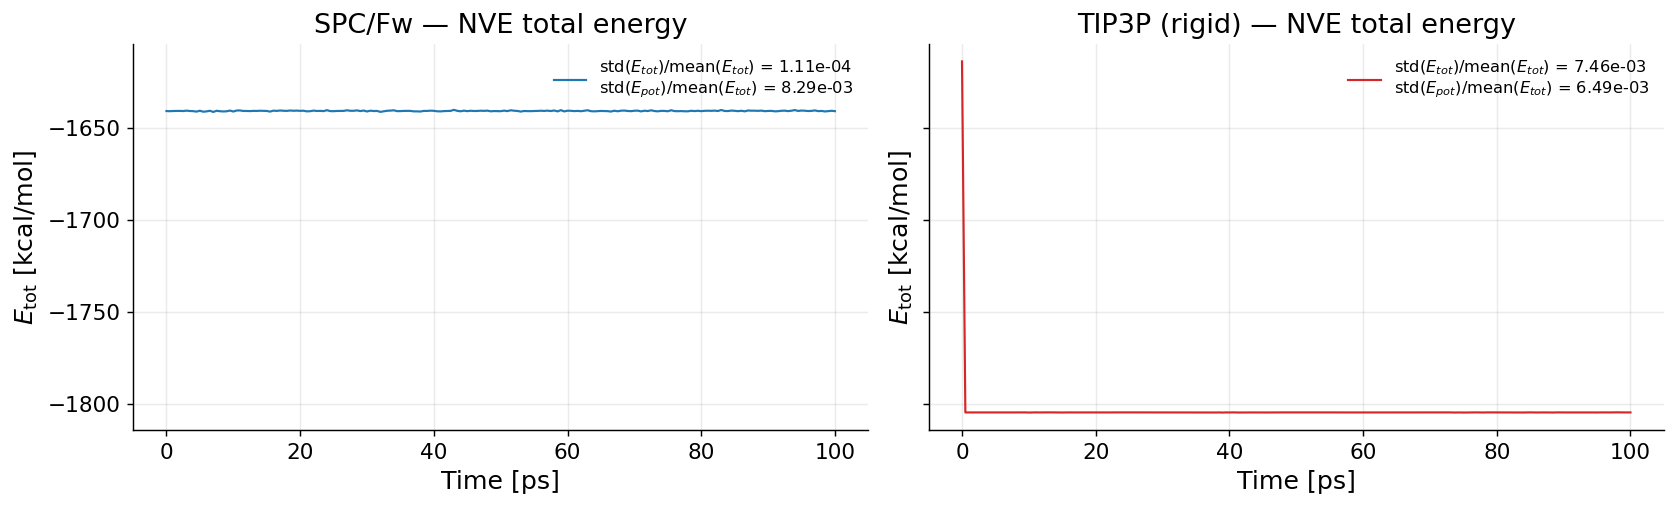

SPC/Fw: std(E_tot)/mean(E_tot) = 1.112e-04; std(E_pot)/mean(E_tot) = 8.291e-03
TIP3P (rigid): std(E_tot)/mean(E_tot) = 7.458e-03; std(E_pot)/mean(E_tot) = 6.490e-03


In [78]:
def parse_lammps_log(log_path: Path) -> pd.DataFrame:
    lines = log_path.read_text().splitlines()
    header, rows, active = None, [], False
    for line in lines:
        s = line.strip()
        if s.startswith("Step ") or s.startswith("Step\t"):
            header, rows, active = s.split(), [], True
        elif active:
            if not s or s[0].isalpha():
                active = False
            else:
                try:
                    vals = [float(x) for x in s.split()]
                    if len(vals) == len(header):
                        rows.append(vals)
                except ValueError:
                    active = False
    return pd.DataFrame(rows, columns=header) if (header and rows) else pd.DataFrame()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
energy_stats = []

for ax, (model, mmeta) in zip(axes, MODELS.items()):
    log = sim_dir(model, "nve") / "log.lammps"
    if not log.exists():
        ax.text(0.5, 0.5, "Run NVE (Exercise 2) first", ha="center", va="center",
                transform=ax.transAxes, color="grey")
        ax.set_title(f"{mmeta['label']} — NVE")
        continue
    df = parse_lammps_log(log)
    if df.empty or "TotEng" not in df.columns or "PotEng" not in df.columns:
        ax.set_title(f"{mmeta['label']} — could not parse log")
        continue
    t_ps = df["Step"].to_numpy() * 0.5 / 1000
    etot = df["TotEng"].to_numpy()
    epot = df["PotEng"].to_numpy()
    mean_etot = np.mean(etot)
    std_etot_over_mean = np.std(etot) / abs(mean_etot)
    std_epot_over_mean = np.std(epot) / abs(mean_etot)
    lbl = (
        rf"std($E_{{tot}}$)/mean($E_{{tot}}$) = {std_etot_over_mean:.2e}" "\n"
        rf"std($E_{{pot}}$)/mean($E_{{tot}}$) = {std_epot_over_mean:.2e}"
    )
    ax.plot(t_ps, etot, color=mmeta["color"], lw=1.2, label=lbl)
    ax.set_xlabel("Time [ps]")
    ax.set_ylabel(r"$E_\mathrm{tot}$ [kcal/mol]")
    ax.set_title(f"{mmeta['label']} — NVE total energy")
    ax.legend(frameon=False, fontsize=9, ncol=2)
    energy_stats.append((mmeta["label"], std_etot_over_mean, std_epot_over_mean))

fig.tight_layout()
plt.show()

for label, std_etot_over_mean, std_epot_over_mean in energy_stats:
    print(
        f"{label}: std(E_tot)/mean(E_tot) = {std_etot_over_mean:.3e}; "
        f"std(E_pot)/mean(E_tot) = {std_epot_over_mean:.3e}"
    )

## 8. Analysis: Temperature (NVE vs Nosé–Hoover vs Langevin)

- **NVE**: temperature fluctuates freely; amplitude $\propto 1/\sqrt{N_f}$.
- **Nosé–Hoover**: deterministic coupling via an extended degree of freedom; $T$ oscillates with period $\tau_\mathrm{damp}$.
- **Langevin**: local stochastic friction; tightest $T$ control but introduces artificial dissipation.

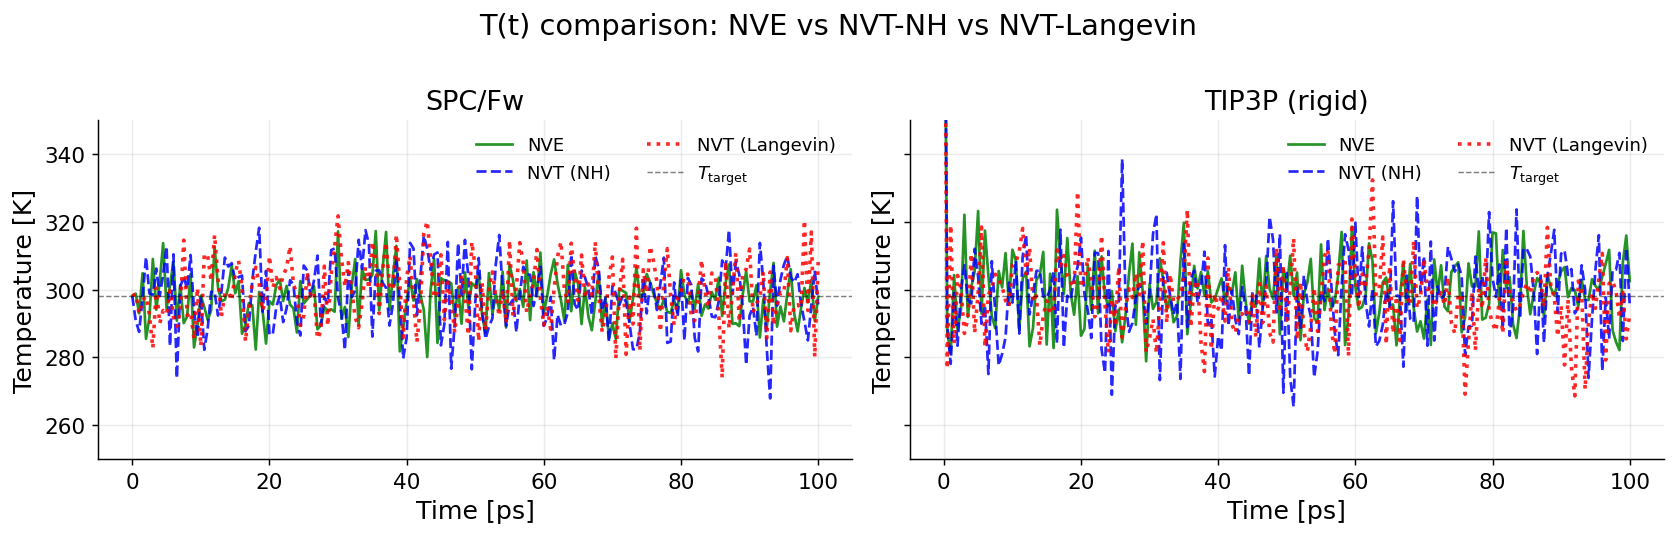

SPC/Fw NVE: mean(T) = 297.58 K; std(T) = 7.01 K
SPC/Fw NVT (NH): mean(T) = 298.27 K; std(T) = 9.70 K
SPC/Fw NVT (Langevin): mean(T) = 299.75 K; std(T) = 9.05 K
TIP3P (rigid) NVE: mean(T) = 300.41 K; std(T) = 13.83 K
TIP3P (rigid) NVT (NH): mean(T) = 298.87 K; std(T) = 16.44 K
TIP3P (rigid) NVT (Langevin): mean(T) = 298.46 K; std(T) = 14.97 K


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
temp_stats = []

for ax, (model, mmeta) in zip(axes, MODELS.items()):
    for thermo, tmeta in THERMOSTATS.items():
        log = sim_dir(model, thermo) / "log.lammps"
        if not log.exists():
            continue
        df = parse_lammps_log(log)
        if df.empty or "Temp" not in df.columns:
            continue
        t_ps = df["Step"].to_numpy() * 0.5 / 1000
        temp = df["Temp"].to_numpy()
        ax.plot(t_ps, temp,
                color=tmeta["color"], ls=tmeta["ls"], lw=tmeta["lw"],
                label=tmeta["label"], alpha=0.85)
        temp_stats.append((mmeta["label"], tmeta["label"], float(np.mean(temp)), float(np.std(temp))))
    ax.axhline(298.15, color="k", lw=0.8, ls="--", alpha=0.5, label="$T_\\mathrm{target}$")
    ax.set_xlabel("Time [ps]")
    ax.set_ylabel("Temperature [K]")
    ax.set_title(mmeta["label"])
    ax.set_ylim(250, 350)
    ax.legend(frameon=False, fontsize=10, ncol=2)

fig.suptitle("T(t) comparison: NVE vs NVT-NH vs NVT-Langevin", y=1.02)
fig.tight_layout()
plt.show()

for model_label, thermo_label, mean_temp, std_temp in temp_stats:
    print(f"{model_label} {thermo_label}: mean(T) = {mean_temp:.2f} K; std(T) = {std_temp:.2f} K")

**Discussion — Energy and temperature control.**

1. Compare the amplitude of $T(t)$ fluctuations between NVE, NH, and Langevin. Which thermostat gives the tightest control? Is tight temperature control always desirable when computing transport properties such as $D$ or $\tau_2$?

## 9. Analysis: Radial Distribution Functions

Each panel shows $g(r)$ for all three thermostat runs (color) and both models (linestyle). **The g(r) should be nearly thermostat-independent** — any significant difference indicates the thermostat is perturbing the structure.

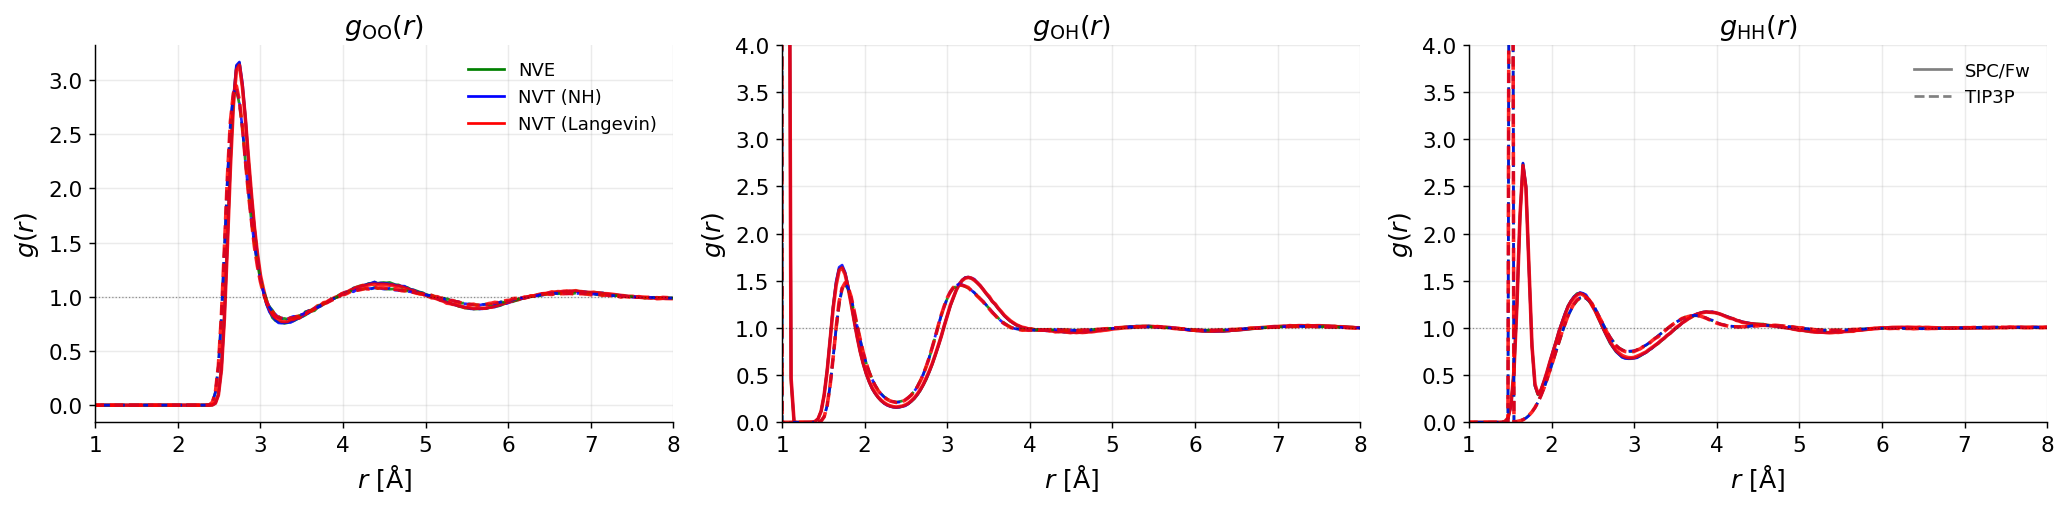

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = [r"$g_{\mathrm{OO}}(r)$", r"$g_{\mathrm{OH}}(r)$", r"$g_{\mathrm{HH}}(r)$"]
fnames = ["rdf_oo.csv", "rdf_oh.csv", "rdf_hh.csv"]
for ax, title in zip(axes, titles):
    ax.set_title(title)

for model, mmeta in MODELS.items():
    ls_model = "-" if model == "spcfw" else "--"
    for thermo, tmeta in THERMOSTATS.items():
        d = sim_dir(model, thermo)
        for ax, fname in zip(axes, fnames):
            csv = d / fname
            if not csv.exists():
                continue
            df  = pd.read_csv(csv)
            lbl = f"{mmeta['label']} {tmeta['label']}"
            ax.plot(df["r_A"], df["g_r"],
                    color=tmeta["color"], ls=ls_model, lw=tmeta["lw"],
                    label=lbl, alpha=0.85)

for ax in axes:
    ax.axhline(1, color="k", lw=0.7, ls=":", alpha=0.4)
    ax.set_xlabel(r"$r$ [Å]")
    ax.set_ylabel(r"$g(r)$")
    ax.set_xlim(1.0, 8.0)
axes[1].set_ylim(0, 4)
axes[2].set_ylim(0, 4)

from matplotlib.lines import Line2D
thermo_handles = [Line2D([0],[0], color=tm["color"], ls="-", lw=1.5, label=tm["label"])
                  for tm in THERMOSTATS.values()]
model_handles  = [
    Line2D([0],[0], color="grey", ls="-",  label="SPC/Fw"),
    Line2D([0],[0], color="grey", ls="--", label="TIP3P"),
]
axes[0].legend(handles=thermo_handles, frameon=False, fontsize=10)
axes[2].legend(handles=model_handles,  frameon=False, fontsize=10)

fig.tight_layout()
plt.show()

**Discussion — Structure.**

2. Are the $g(r)$ peaks thermostat-dependent? What does this tell you about the effect of thermostats on equilibrium (structural) vs. dynamical properties?

## 10. Analysis: VACF and Diffusion Coefficient

Color = thermostat, linestyle = model. The running integral $D(t)$ should plateau at the same value regardless of thermostat for a well-behaved simulation. Differences reveal thermostat artefacts in the velocity autocorrelation.

[spcfw/nve] D_VACF = 2.198  [1e-5 cm^2/s]  (tmax=1.2 ps)
[spcfw/nvt_nh] D_VACF = 2.164  [1e-5 cm^2/s]  (tmax=1.2 ps)
[spcfw/nvt_lang] D_VACF = 1.594  [1e-5 cm^2/s]  (tmax=1.2 ps)
[tip3p/nve] D_VACF = 3.730  [1e-5 cm^2/s]  (tmax=1.2 ps)
[tip3p/nvt_nh] D_VACF = 3.601  [1e-5 cm^2/s]  (tmax=1.2 ps)
[tip3p/nvt_lang] D_VACF = 2.131  [1e-5 cm^2/s]  (tmax=1.2 ps)


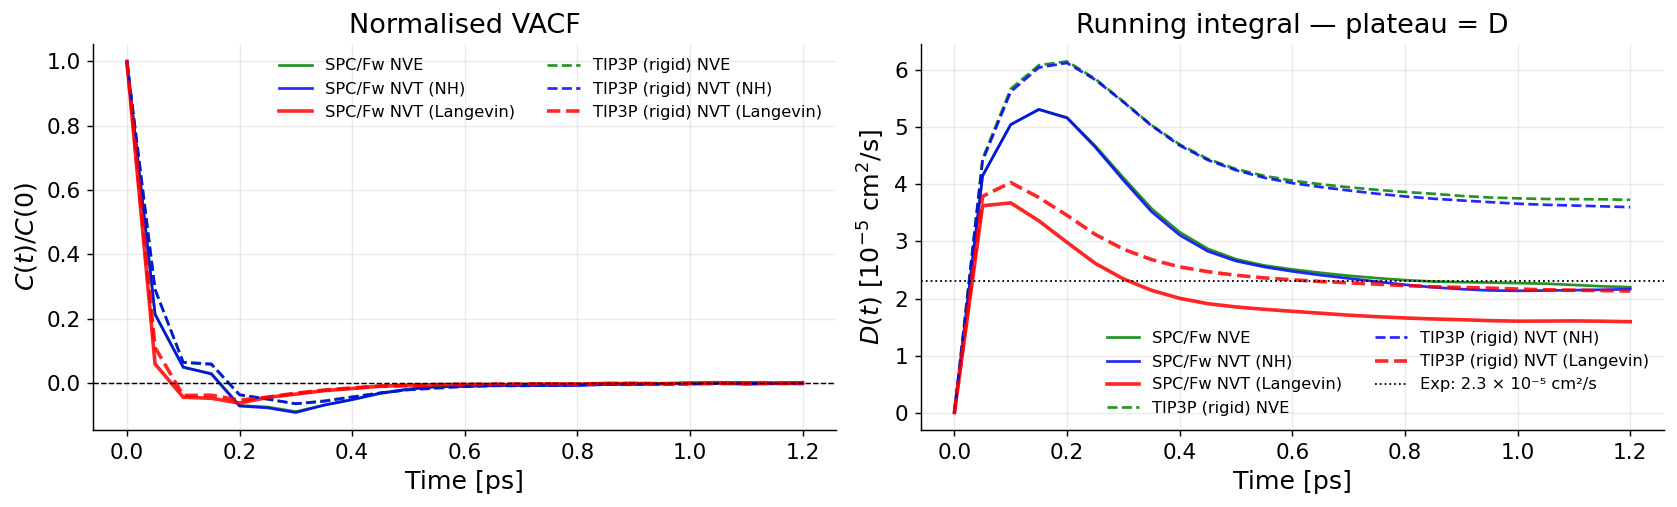

In [81]:
vacf_data: dict[tuple, dict] = {}

for model in ("spcfw", "tip3p"):
    for thermo in THERMOSTATS:
        csv = sim_dir(model, thermo) / "vacf_H2O_COM.csv"
        if not csv.exists():
            continue
        df = pd.read_csv(csv)
        t  = df["time_fs"].to_numpy()
        c  = df["vacf"].to_numpy()
        cn = df["vacf_normalized"].to_numpy()
        dt = float(t[1] - t[0]) if len(t) > 1 else DUMP_DT_FS
        # CSV stores per-component VACF (C_vector/3): D = integral, no extra 1/3
        d_t = mv.cumulative_integrate_trapz(c, dt / T_AU_FS) * AU_DIFF_TO_1E5_CM2_S
        tmax = VACF_TMAX_FS[model]
        if tmax is not None:
            mask = t <= tmax
            t, c, cn, d_t = t[mask], c[mask], cn[mask], d_t[mask]
        vacf_data[(model, thermo)] = {"t": t, "vacf_norm": cn, "D_t": d_t}
        print(f"[{model}/{thermo}] D_VACF = {d_t[-1]:.3f}  [1e-5 cm^2/s]  (tmax={t[-1]/1000:.1f} ps)")

if vacf_data:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for (model, thermo), d in vacf_data.items():
        mmeta, tmeta = MODELS[model], THERMOSTATS[thermo]
        ls  = "-" if model == "spcfw" else "--"
        lbl = f"{mmeta['label']} {tmeta['label']}"
        t_ps = d["t"] / 1000
        axes[0].plot(t_ps, d["vacf_norm"], color=tmeta["color"], ls=ls, lw=tmeta["lw"], label=lbl, alpha=0.85)
        axes[1].plot(t_ps, d["D_t"],       color=tmeta["color"], ls=ls, lw=tmeta["lw"], label=lbl, alpha=0.85)
    axes[0].axhline(0, color="k", lw=0.8, ls="--")
    axes[0].set_xlabel("Time [ps]"); axes[0].set_ylabel("$C(t)/C(0)$")
    axes[0].set_title("Normalised VACF"); axes[0].legend(frameon=False, fontsize=9, ncol=2)
    axes[1].axhline(D_EXP, color="k", lw=1.0, ls=":", label=f"Exp: {D_EXP} × 10⁻⁵ cm²/s")
    axes[1].set_xlabel("Time [ps]"); axes[1].set_ylabel(r"$D(t)$ [$10^{-5}$ cm$^2$/s]")
    axes[1].set_title("Running integral — plateau = D"); axes[1].legend(frameon=False, fontsize=9, ncol=2)
    fig.tight_layout(); plt.show()

## 11. Analysis: MSD

[spcfw/nve] D_MSD = 2.005  [1e-5 cm^2/s]  (fit: 20.0–90.0 ps, R^2=0.9918, n=1401)
[spcfw/nvt_nh] D_MSD = 1.981  [1e-5 cm^2/s]  (fit: 20.0–90.0 ps, R^2=0.9927, n=1401)
[spcfw/nvt_lang] D_MSD = 1.067  [1e-5 cm^2/s]  (fit: 20.0–90.0 ps, R^2=0.9879, n=1401)
[tip3p/nve] D_MSD = 3.751  [1e-5 cm^2/s]  (fit: 20.0–90.0 ps, R^2=0.9937, n=1401)
[tip3p/nvt_nh] D_MSD = 3.645  [1e-5 cm^2/s]  (fit: 20.0–90.0 ps, R^2=0.9972, n=1401)
[tip3p/nvt_lang] D_MSD = 1.415  [1e-5 cm^2/s]  (fit: 20.0–90.0 ps, R^2=0.9922, n=1401)


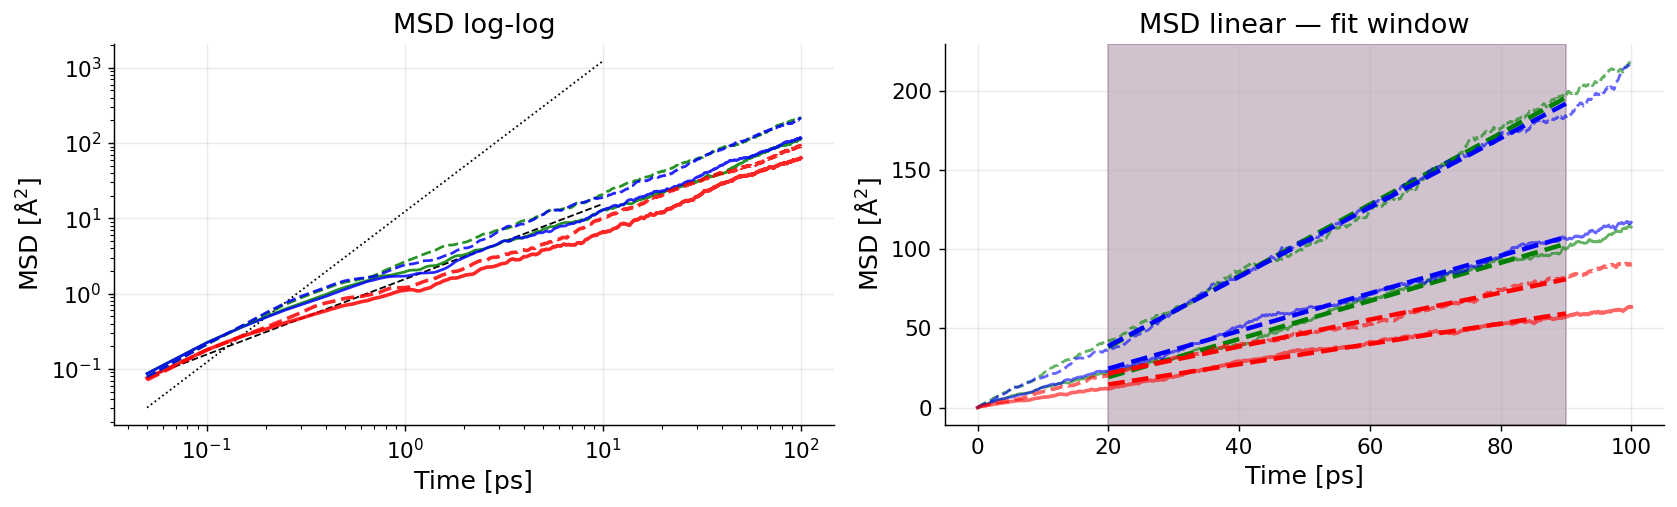

In [82]:
msd_data: dict[tuple, dict] = {}

for model in ("spcfw", "tip3p"):
    for thermo in THERMOSTATS:
        csv = sim_dir(model, thermo) / "msd_H2O_COM.csv"
        if not csv.exists():
            continue
        df   = pd.read_csv(csv)
        t    = df["time_fs"].to_numpy()
        msd  = df["msd_A2"].to_numpy()
        dt   = float(t[1] - t[0]) if len(t) > 1 else DUMP_DT_FS
        res  = mv.diffusion_from_msd(msd, dt, dim=3,
                                     fit_start_fs=MSD_FIT_START_FS[model],
                                     fit_end_fs=MSD_FIT_END_FS[model])
        D_msd = res.get("D_msd_1e-5_cm^2/s", float("nan"))
        fit_start = res.get("D_msd_fit_start_fs")
        fit_end   = res.get("D_msd_fit_end_fs")

        slope = float("nan")
        intercept = float("nan")
        r2 = float("nan")
        n_fit = 0
        if fit_start is not None and fit_end is not None:
            mask_fit = (t >= fit_start) & (t <= fit_end)
            n_fit = int(mask_fit.sum())
            if n_fit > 1:
                t_fit = t[mask_fit]
                msd_fit = msd[mask_fit]
                dt_centered = t_fit - t_fit.mean()
                slope = float(np.dot(dt_centered, msd_fit - msd_fit.mean()) / np.dot(dt_centered, dt_centered))
                intercept = float(msd_fit.mean() - slope * t_fit.mean())
                msd_pred = slope * t_fit + intercept
                ss_res = float(np.sum((msd_fit - msd_pred)**2))
                ss_tot = float(np.sum((msd_fit - msd_fit.mean())**2))
                r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

        msd_data[(model, thermo)] = {
            "t": t, "msd": msd,
            "fit_start": fit_start,
            "fit_end":   fit_end,
            "fit_slope": slope,
            "fit_intercept": intercept,
            "fit_r2": r2,
            "fit_n": n_fit,
            "D_msd":     D_msd,
        }
        print(f"[{model}/{thermo}] D_MSD = {D_msd:.3f}  [1e-5 cm^2/s]  "
              f"(fit: {fit_start/1000 if fit_start is not None else 0:.1f}–"
              f"{fit_end/1000 if fit_end is not None else 0:.1f} ps, "
              f"R^2={r2:.4f}, n={n_fit})")

if msd_data:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    # Reference slopes for log-log, anchored to the data so they sit in the right range.
    t_ref_ps = np.geomspace(0.05, 10.0, 200)
    t_ballistic_anchor_ps = 0.2
    t_diffusive_anchor_ps = 3.0
    msd_ballistic_anchor = []
    msd_diffusive_anchor = []
    for d in msd_data.values():
        t_ps_all = d["t"] / 1000
        msd_all = d["msd"]
        mask_pos = msd_all > 0
        if not np.any(mask_pos):
            continue
        i_ball = np.argmin(np.abs(t_ps_all[mask_pos] - t_ballistic_anchor_ps))
        i_diff = np.argmin(np.abs(t_ps_all[mask_pos] - t_diffusive_anchor_ps))
        msd_ballistic_anchor.append(msd_all[mask_pos][i_ball])
        msd_diffusive_anchor.append(msd_all[mask_pos][i_diff])
    if msd_ballistic_anchor and msd_diffusive_anchor:
        y_ball = float(np.median(msd_ballistic_anchor))
        y_diff = float(np.median(msd_diffusive_anchor))
        axes[0].plot(t_ref_ps, y_ball * (t_ref_ps / t_ballistic_anchor_ps)**2,
                     'k:', lw=1, label="slope 2 (ballistic)")
        axes[0].plot(t_ref_ps, y_diff * (t_ref_ps / t_diffusive_anchor_ps),
                     'k--', lw=1, label="slope 1 (diffusive)")

    for (model, thermo), d in msd_data.items():
        mmeta, tmeta = MODELS[model], THERMOSTATS[thermo]
        ls   = "-" if model == "spcfw" else "--"
        lbl  = f"{mmeta['label']} {tmeta['label']}"
        t_ps = d["t"] / 1000
        mask = d["msd"] > 0
        m    = d.get("fit_slope", float("nan"))
        q    = d.get("fit_intercept", float("nan"))
        r2   = d.get("fit_r2", float("nan"))
        axes[0].loglog(t_ps[mask], d["msd"][mask], color=tmeta["color"], ls=ls, lw=tmeta["lw"], label=lbl, alpha=0.85)
        axes[1].plot(t_ps, d["msd"], color=tmeta["color"], ls=ls, lw=tmeta["lw"], alpha=0.6)
        t0, t1 = d["fit_start"], d["fit_end"]
        if not np.isnan(d["D_msd"]) and t0 and t1 and not np.isnan(m) and not np.isnan(q):
            mask_f = (d["t"] >= t0) & (d["t"] <= t1)
            if mask_f.sum() > 1:
                tw = d["t"][mask_f]
                msd_line = m * tw + q
                fit_lbl = f"{lbl} fit: D={d['D_msd']:.3f}"
                if not np.isnan(r2):
                    fit_lbl += f", R^2={r2:.4f}"
                axes[1].plot(tw/1000, msd_line, color=tmeta["color"], lw=2.5, ls="--", label=fit_lbl)
                axes[1].axvspan(t0/1000, t1/1000, alpha=0.05, color=tmeta["color"])

    axes[0].set_xlabel("Time [ps]"); axes[0].set_ylabel(r"MSD [Å$^2$]")
    axes[0].set_title("MSD log-log"); axes[0].legend(frameon=False, fontsize=9, ncol=2)
    axes[1].set_xlabel("Time [ps]"); axes[1].set_ylabel(r"MSD [Å$^2$]")
    axes[1].set_title("MSD linear — fit window")
    fig.tight_layout(); plt.show()

## 12. Analysis: Rotational Relaxation Time $\tau_2$

$C_2(t)$ is fitted to $e^{-t/\tau_2}$ in the region $[t_\mathrm{start}, t_\mathrm{end}]$ where the decay is roughly exponential (avoid very short times where librational motion dominates and long times where noise takes over). The integral estimate $\tau_2 = \int C_2\,dt$ from the pre-computation is also shown.

The experimental value is $\tau_2^\mathrm{exp} \approx 2$ ps (from NMR relaxation at 298 K).

[spcfw/nve] τ₂ (integral) = 1.82 ps  |  τ₂ (fit) = 1.56 ps
[spcfw/nvt_nh] τ₂ (integral) = 1.83 ps  |  τ₂ (fit) = 1.58 ps
[spcfw/nvt_lang] τ₂ (integral) = 2.56 ps  |  τ₂ (fit) = 2.18 ps
[tip3p/nve] τ₂ (integral) = 1.04 ps  |  τ₂ (fit) = 1.01 ps
[tip3p/nvt_nh] τ₂ (integral) = 1.17 ps  |  τ₂ (fit) = 1.05 ps
[tip3p/nvt_lang] τ₂ (integral) = 1.92 ps  |  τ₂ (fit) = 1.63 ps


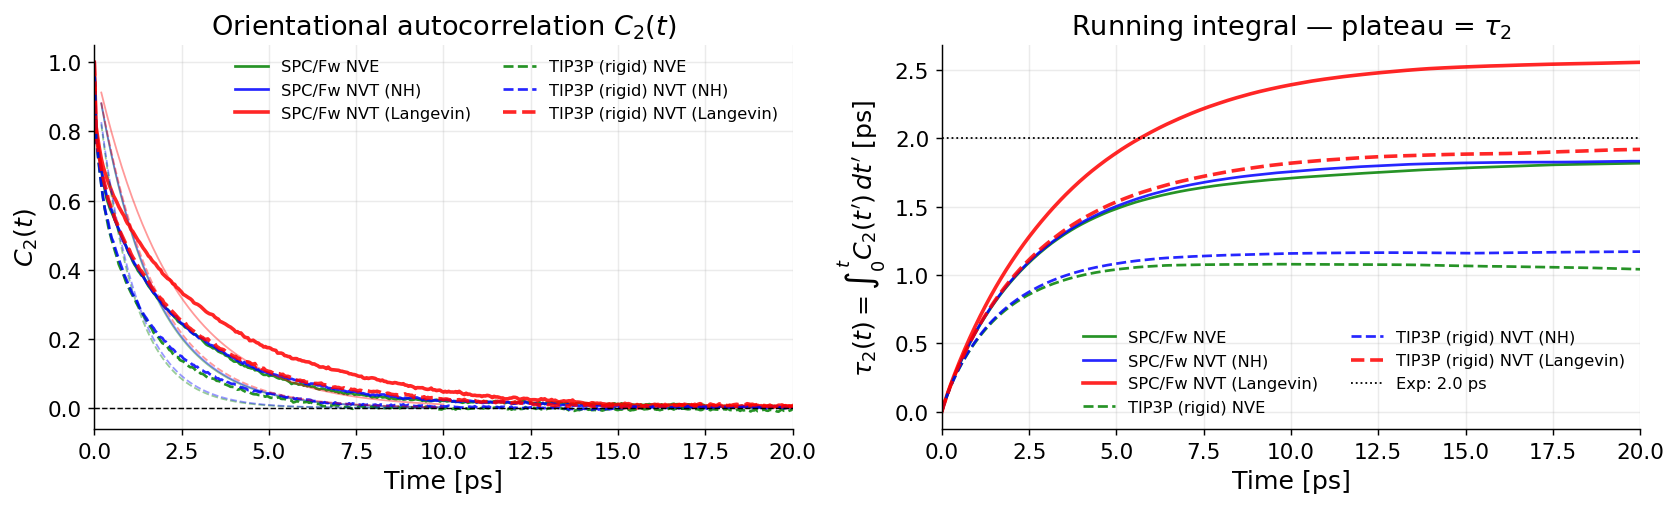

In [83]:
rot_data: dict[tuple, dict] = {}

def exp_decay(t, tau):
    return np.exp(-t / tau)

for model in ("spcfw", "tip3p"):
    for thermo in THERMOSTATS:
        d = sim_dir(model, thermo)
        rot_csvs = sorted(d.glob("rot_relax_dipole*.csv"))
        if not rot_csvs:
            continue
        csv = rot_csvs[-1]
        df = pd.read_csv(csv)
        t_ps = df["time_ps"].to_numpy()
        c2   = df["C2"].to_numpy()
        dt_ps = float(t_ps[1] - t_ps[0]) if len(t_ps) > 1 else np.nan
        tau2_t = mv.cumulative_integrate_trapz(c2, dt_ps) if len(t_ps) > 1 else np.array([0.0])

        # integral tau2 from summary file
        tau2_int = float("nan")
        summary_csvs = sorted(d.glob("rot_relax_summary_dipole*.csv"))
        if summary_csvs:
            summary = summary_csvs[-1]
            sdf = pd.read_csv(summary)
            tau2_int = float(sdf["tau2_integral_ps"].iloc[0])
        elif len(t_ps) > 1:
            tau2_int = float(tau2_t[-1])

        # exponential fit (0.2 ps to 5 ps, where decay is roughly exponential)
        tau2_fit = float("nan")
        try:
            mask_fit = (t_ps >= 0.2) & (t_ps <= 5.0) & (c2 > 0)
            if mask_fit.sum() > 5:
                popt, _ = curve_fit(exp_decay, t_ps[mask_fit], c2[mask_fit], p0=[2.0])
                tau2_fit = float(popt[0])
        except Exception:
            pass

        rot_data[(model, thermo)] = {
            "t_ps": t_ps,
            "C2": c2,
            "tau2_t": tau2_t,
            "tau2_int": tau2_int,
            "tau2_fit": tau2_fit,
        }
        print(f"[{model}/{thermo}] τ₂ (integral) = {tau2_int:.2f} ps  |  τ₂ (fit) = {tau2_fit:.2f} ps")

if rot_data:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    t_fit_line = np.linspace(0.2, 10, 200)
    for (model, thermo), d in rot_data.items():
        mmeta, tmeta = MODELS[model], THERMOSTATS[thermo]
        ls  = "-" if model == "spcfw" else "--"
        lbl = f"{mmeta['label']} {tmeta['label']}"
        axes[0].plot(d["t_ps"], d["C2"], color=tmeta["color"], ls=ls, lw=tmeta["lw"], label=lbl, alpha=0.85)
        axes[1].plot(d["t_ps"], d["tau2_t"], color=tmeta["color"], ls=ls, lw=tmeta["lw"], label=lbl, alpha=0.85)
        if not np.isnan(d["tau2_fit"]):
            axes[0].plot(t_fit_line, exp_decay(t_fit_line, d["tau2_fit"]),
                         color=tmeta["color"], ls=ls, lw=1.0, alpha=0.4)

    axes[0].axhline(0, color="k", lw=0.8, ls="--")
    axes[0].set_xlim(0, max(ROT_TMAX_PS.values()))
    axes[0].set_xlabel("Time [ps]")
    axes[0].set_ylabel(r"$C_2(t)$")
    axes[0].set_title(r"Orientational autocorrelation $C_2(t)$")
    axes[0].legend(frameon=False, fontsize=9, ncol=2)

    axes[1].axhline(TAU2_EXP, color="k", lw=1.0, ls=":", label=f"Exp: {TAU2_EXP:.1f} ps")
    axes[1].set_xlim(0, max(ROT_TMAX_PS.values()))
    axes[1].set_xlabel("Time [ps]")
    axes[1].set_ylabel(r"$\tau_2(t)=\int_0^t C_2(t')\,dt'$ [ps]")
    axes[1].set_title(r"Running integral — plateau = $\tau_2$")
    axes[1].legend(frameon=False, fontsize=9, ncol=2)

    fig.tight_layout(); plt.show()

## 13. Summary Table

All dynamical observables for every model × thermostat combination, compared with experiment.

In [84]:
rows = []
for model, mmeta in MODELS.items():
    for thermo, tmeta in THERMOSTATS.items():
        key = (model, thermo)
        D_v   = float(vacf_data[key]["D_t"][-1]) if key in vacf_data else float("nan")
        D_m   = msd_data[key]["D_msd"]           if key in msd_data  else float("nan")
        t2_f  = rot_data[key]["tau2_fit"]         if key in rot_data  else float("nan")
        t2_i  = rot_data[key]["tau2_int"]         if key in rot_data  else float("nan")

        def fmt(v):
            return round(v, 3) if not np.isnan(v) else "—"

        rows.append({
            "Model":              mmeta["label"],
            "Thermostat":         tmeta["label"],
            "D_VACF [1e-5 cm²/s]": fmt(D_v),
            "D_MSD  [1e-5 cm²/s]": fmt(D_m),
            "τ₂ fit [ps]":         fmt(t2_f),
            "τ₂ int [ps]":         fmt(t2_i),
        })

df_sum = pd.DataFrame(rows).set_index(["Model", "Thermostat"])
display(df_sum)

print(f"\nReference (experiment, 298 K):  D = {D_EXP} × 10⁻⁵ cm²/s   |   τ₂ ≈ {TAU2_EXP} ps")

D_VACF [1e-5 cm²/s]  D_MSD  [1e-5 cm²/s]  \
Model         Thermostat                                                 
SPC/Fw        NVE                           2.198                2.005   
              NVT (NH)                      2.164                1.981   
              NVT (Langevin)                1.594                1.067   
TIP3P (rigid) NVE                           3.730                3.751   
              NVT (NH)                      3.601                3.645   
              NVT (Langevin)                2.131                1.415   

                              τ₂ fit [ps]  τ₂ int [ps]  
Model         Thermostat                                
SPC/Fw        NVE                   1.563        1.818  
              NVT (NH)              1.583        1.833  
              NVT (Langevin)        2.183        2.557  
TIP3P (rigid) NVE                   1.010        1.042  
              NVT (NH)              1.052        1.171  
              NVT (Langevin)        1.631        1.919


Reference (experiment, 298 K):  D = 2.3 × 10⁻⁵ cm²/s   |   τ₂ ≈ 2.0 ps


**Discussion — Thermostat effects on dynamics and model comparison.**

3. Does the choice of thermostat affect $D$ or $\tau_2$? Which run (NVE, NH, Langevin) should be most reliable for computing dynamical observables, and why?

4. Which water model gives $D$ and $\tau_2$ closer to experiment? Are the two models consistently better or worse across all observables, or does the answer depend on the observable?